##Introduction
Sentiment Analyzers are a part of Natural Language Processing (NLP). NLP, simply put, is a machine learning technology that allows computers to understand human language. Chances are, you're already familiar with this technology or have even used it yourself! Smart assistants like Siri and Alexa, chatbots like ChatGPT and Gemini, and tools like Grammarly all leverage NLP.

Sentiment Analysis, also referred to as opinion mining, is a specific application within NLP focused on analyzing the emotional tone of text. It aims to classify text as positive, negative, or neutral. For instance, classifying YouTube comments under a video helps creators understand what type of content resonates with their viewers. Similarly, analyzing product reviews helps companies gauge how well their products are performing in the market. As you can see, sentiment analysis holds significant importance.
Now that you have a basic understanding of this field, let's waste no more time and dive into the project itself!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset Link: [Click Here](https://www.kaggle.com/datasets/alexandrakim2201/spotify-dataset)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset.csv')
df.head()

,Review,label
0,"Great music service, the audio is high quality...",POSITIVE
1,Please ignore previous negative rating. This a...,POSITIVE
2,"This pop-up ""Get the best Spotify experience o...",NEGATIVE
3,Really buggy and terrible to use as of recently,NEGATIVE
4,Dear Spotify why do I get songs that I didn't ...,NEGATIVE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52702 entries, 0 to 52701
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  52686 non-null  object
 1   label   52702 non-null  object
dtypes: object(2)
memory usage: 823.6+ KB


In [ ]:
df.isnull().sum()

,0
Review,16
label,0


In [ ]:
df = df.dropna(subset=['Review'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52686 entries, 0 to 52701
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  52686 non-null  object
 1   label   52686 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [ ]:
df['label'].value_counts()

,count
label,
NEGATIVE,29423
POSITIVE,23263


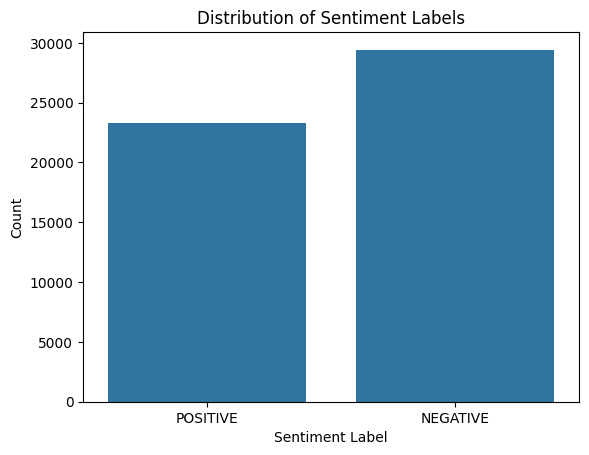

In [ ]:
# Visualize the distribution of labels (positive, negative, etc.)
sns.countplot(x='label', data=df)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

##**Understanding the clean_text function**


**text = re.sub(r'Ã[\x80-\xBF]+', ' ', text):** Removes encoded symbols that appear as characters like Ã, Å, Ë.

**text = re.sub(r'[^a-zA-Z\s]', ' ', text):** The symbol "^" at the start of the square brackets means "not". Hence we are replacing all symbols that are not lower and upper case alphabels(a-z,A-Z) or white space(/s) with an empty string with a space.

**text = re.sub(r'\s+', ' ', text):** At last i replaced all multiple spaces with a single space to ensure readability. The strip function removes any leading or trailing whitespaces and we convert all reviews to lower case.


In [ ]:
def clean_text(text):
    text = re.sub(r'Ã[\x80-\xBF]+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text.lower()

In [ ]:
df['Review'] = df['Review'].apply(clean_text)

In [ ]:
#VIEW THE CLEANED TEXTS IN "Review" column again
pd.set_option('display.max_colwidth', None) #to view text fully and so that
#pandas doesn't truncate the text

print(df.iloc[283]['Review']) #view entry 283

i really like a sound hello everyone have a nice day stay safe always god bless


In [ ]:
print(df.iloc[428]['Review'])
#Before cleaning:Best music streaming app ever! Ã°Å¸â€˜Å’Ã°Å¸â€˜Â
#After cleaning:Best music streaming app ever

best music streaming app ever


## Tokenization

Tokenization is the process of breaking down a string of text into smaller units, or tokens, which essentially are meaningful words.

We require an individual meaniningful entity to work upon which can only be words and not sentences.

Example:
good, great, wow etc signal a positive review.

bad, lame, boring etc signal a negative review.

In [ ]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

df['Tokens'] = df['Review'].apply(tokenize_text)

print(df.iloc[283]['Tokens'])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['i', 'really', 'like', 'a', 'sound', 'hello', 'everyone', 'have', 'a', 'nice', 'day', 'stay', 'safe', 'always', 'god', 'bless']


In [ ]:
df.head()

,Review,label,Tokens
0,great music service the audio is high quality and the app is easy to use also very quick and friendly support,POSITIVE,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]"
1,please ignore previous negative rating this app is super great i give it five stars,POSITIVE,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]"
2,this pop up get the best spotify experience on android is too annoying please let s get rid of this,NEGATIVE,"[this, pop, up, get, the, best, spotify, experience, on, android, is, too, annoying, please, let, s, get, rid, of, this]"
3,really buggy and terrible to use as of recently,NEGATIVE,"[really, buggy, and, terrible, to, use, as, of, recently]"
4,dear spotify why do i get songs that i didn t put on my playlist and why do we have shuffle play,NEGATIVE,"[dear, spotify, why, do, i, get, songs, that, i, didn, t, put, on, my, playlist, and, why, do, we, have, shuffle, play]"


## Removing Stopwords

Stop words are words that have less meaningful value/contribution to our analysis. Words like i, he, she, they, went, want, for, in etc hold little to no value and hence are better off removed.

You can also create a list of custom stop words specific to your domain. For example words like music, app, playlist etc are common stop words for this dataset.



In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))
    if custom_stopwords:
        stop_words.update(custom_stopwords)
    return [word for word in tokens if word.lower() not in stop_words]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#my list of custom_stop_words

custom_stopwords = {'app', 'music','play', 'spotify', 'song', 'songs', 'listen', 'playing','get', 'playlist'}
df['Filtered_Tokens'] = df['Tokens'].apply(remove_stopwords)

In [ ]:
df.head()

,Review,label,Tokens,Filtered_Tokens
0,great music service the audio is high quality and the app is easy to use also very quick and friendly support,POSITIVE,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, service, audio, high, quality, easy, use, also, quick, friendly, support]"
1,please ignore previous negative rating this app is super great i give it five stars,POSITIVE,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]","[please, ignore, previous, negative, rating, super, great, give, five, stars]"
2,this pop up get the best spotify experience on android is too annoying please let s get rid of this,NEGATIVE,"[this, pop, up, get, the, best, spotify, experience, on, android, is, too, annoying, please, let, s, get, rid, of, this]","[pop, best, experience, android, annoying, please, let, rid]"
3,really buggy and terrible to use as of recently,NEGATIVE,"[really, buggy, and, terrible, to, use, as, of, recently]","[really, buggy, terrible, use, recently]"
4,dear spotify why do i get songs that i didn t put on my playlist and why do we have shuffle play,NEGATIVE,"[dear, spotify, why, do, i, get, songs, that, i, didn, t, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, put, shuffle]"


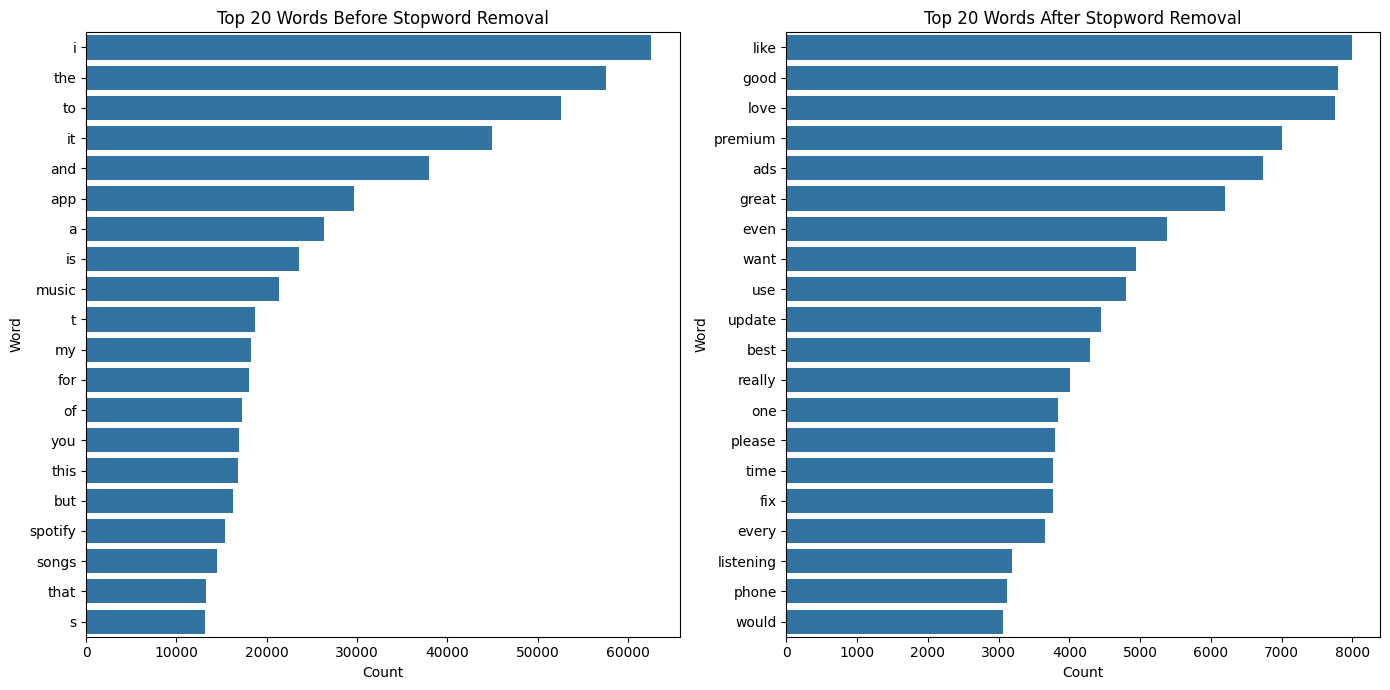

In [ ]:
# Before stopword removal (use word counts before applying remove_stopwords)
all_tokens = [word for tokens in df['Tokens'] for word in tokens]
word_counts_before_removal = Counter(all_tokens)
most_common_words_before_removal = word_counts_before_removal.most_common(20)

# After stopword removal
word_counts_after_removal = Counter(all_filtered_tokens)
most_common_words_after_removal = word_counts_after_removal.most_common(20)

# Create DataFrame for plotting
before_df = pd.DataFrame(most_common_words_before_removal, columns=['Word', 'Count'])
after_df = pd.DataFrame(most_common_words_after_removal, columns=['Word', 'Count'])

# Plot before and after stopword removal
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(x='Count', y='Word', data=before_df, ax=axes[0])
axes[0].set_title('Top 20 Words Before Stopword Removal')

sns.barplot(x='Count', y='Word', data=after_df, ax=axes[1])
axes[1].set_title('Top 20 Words After Stopword Removal')

plt.tight_layout()
plt.show()

In [ ]:
#I used this to identify/modify my list of custom stop words.
from collections import Counter
all_filtered_tokens = [word for tokens in df['Filtered_Tokens'] for word in tokens]

# Count the occurrences of each word after removing stopwords
word_counts_after_removal = Counter(all_filtered_tokens)

# Get the 20 most common words after removing stopwords
most_common_words_after_removal = word_counts_after_removal.most_common(20)
print(most_common_words_after_removal)


#choosing custom stop words is tricky as it's debatable whether they contribute
#to the accuracy or not. I've selected just a few from top 20.

[('like', 7991), ('good', 7803), ('love', 7758), ('premium', 7003), ('ads', 6743), ('great', 6206), ('even', 5382), ('want', 4948), ('use', 4802), ('update', 4453), ('best', 4291), ('really', 4006), ('one', 3845), ('please', 3797), ('time', 3773), ('fix', 3761), ('every', 3650), ('listening', 3185), ('phone', 3123), ('would', 3063)]


## Steming

Stemming reduces words to their root form (or stem).
Note: may not always be a valid word in the language.

For example:
"playing" might be stemmed to "play"

"studying" might be stemmed to "study"

"running" might be stemmed to "run"

"ring" might be stemmed to "r"  (ineffiency)

##Lemmatization

Lemmatization reduces words to their base or dictionary form (lemma) by considering their dictionary meaning hence providing more accuracy than stemming.

For example:

"running" becomes "run,"

"better" becomes "good."

"ring" remains "ring."

In [ ]:
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

unzip:  cannot find or open /usr/share/nltk_data/corpora/wordnet.zip, /usr/share/nltk_data/corpora/wordnet.zip.zip or /usr/share/nltk_data/corpora/wordnet.zip.ZIP.


In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to perform lemmatization
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word, pos='v') for word in tokens]

#pos is set to v (verb) for better accuracy. Refer below manual to understand more.
df['Lemmatized_Tokens'] = df['Filtered_Tokens'].apply(lemmatize_tokens)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df.head()

,Review,label,Tokens,Filtered_Tokens,Lemmatized_Tokens
0,great music service the audio is high quality and the app is easy to use also very quick and friendly support,POSITIVE,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, service, audio, high, quality, easy, use, also, quick, friendly, support]","[great, service, audio, high, quality, easy, use, also, quick, friendly, support]"
1,please ignore previous negative rating this app is super great i give it five stars,POSITIVE,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]","[please, ignore, previous, negative, rating, super, great, give, five, stars]","[please, ignore, previous, negative, rat, super, great, give, five, star]"
2,this pop up get the best spotify experience on android is too annoying please let s get rid of this,NEGATIVE,"[this, pop, up, get, the, best, spotify, experience, on, android, is, too, annoying, please, let, s, get, rid, of, this]","[pop, best, experience, android, annoying, please, let, rid]","[pop, best, experience, android, annoy, please, let, rid]"
3,really buggy and terrible to use as of recently,NEGATIVE,"[really, buggy, and, terrible, to, use, as, of, recently]","[really, buggy, terrible, use, recently]","[really, buggy, terrible, use, recently]"
4,dear spotify why do i get songs that i didn t put on my playlist and why do we have shuffle play,NEGATIVE,"[dear, spotify, why, do, i, get, songs, that, i, didn, t, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, put, shuffle]","[dear, put, shuffle]"


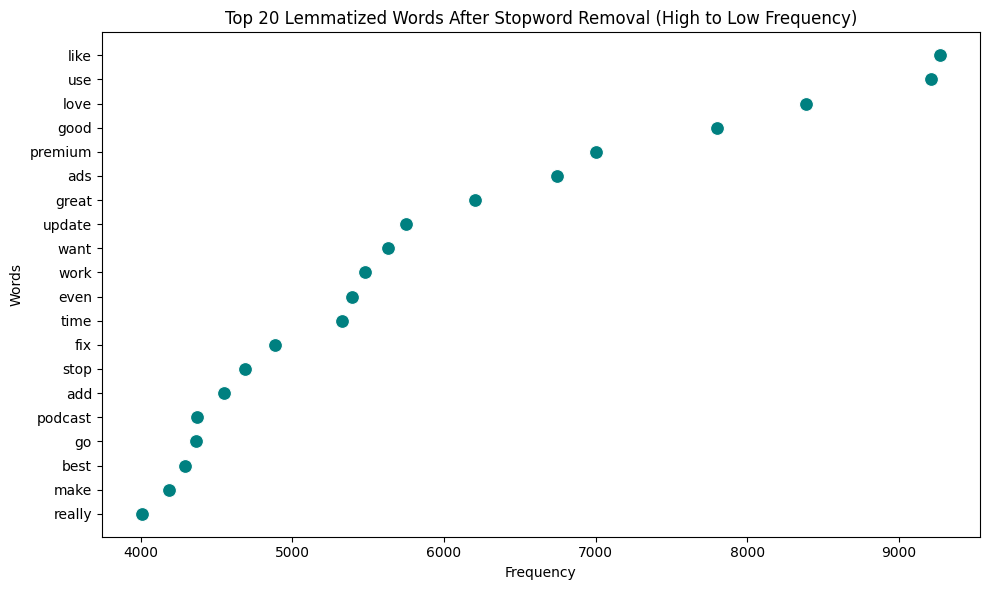

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Flatten the list of filtered (lemmatized) tokens after stopword removal
all_lemmatized_tokens_after = [word for tokens in df['Lemmatized_Tokens'] for word in tokens if word not in custom_stopwords]

# Count the frequency of each word after stopword removal
word_counts_lemmatized_after = Counter(all_lemmatized_tokens_after)

# Get the 20 most common words sorted by frequency (high to low)
most_common_lemmatized_after = word_counts_lemmatized_after.most_common(20)

# Convert to DataFrame for easier plotting
after_lemmatized_df = pd.DataFrame(most_common_lemmatized_after, columns=['Word', 'Count'])
after_lemmatized_df = after_lemmatized_df.sort_values(by='Count', ascending=False)  # Sort by frequency (high to low)

# **Plotting**
plt.figure(figsize=(10, 6))

# Dot plot for after stopword removal (lemmatized tokens), sorted from high to low frequency
sns.scatterplot(x='Count', y='Word', data=after_lemmatized_df, marker='o', s=100, color='teal')

# Add titles and labels
plt.title('Top 20 Lemmatized Words After Stopword Removal (High to Low Frequency)')
plt.xlabel('Frequency')
plt.ylabel('Words')

plt.tight_layout()
plt.show()


## Feature Extraction using TF-IDF

TF-IDF is a natural language processing (NLP) technique that's used to evaluate the importance of different words in a sentence.


It's simple, intuitive technique which utilizes a fixed size input.
It captures the importance of words (hence the semantics) while reducing the influence of stopwords alongside.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Performing TF-IDF vectorization
def apply_tfidf(df):
    df['TFIDF_Tokens'] = df['Lemmatized_Tokens'].apply(lambda x: ' '.join(x))
    tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
    tfidf_matrix = tfidf_vectorizer.fit_transform(df['TFIDF_Tokens'])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    return tfidf_matrix, feature_names

# Applying TF-IDF on our Dataframe
tfidf_matrix, feature_names = apply_tfidf(df)
df.head()

,Review,label,Tokens,Filtered_Tokens,Lemmatized_Tokens,TFIDF_Tokens
0,great music service the audio is high quality and the app is easy to use also very quick and friendly support,POSITIVE,"[great, music, service, the, audio, is, high, quality, and, the, app, is, easy, to, use, also, very, quick, and, friendly, support]","[great, service, audio, high, quality, easy, use, also, quick, friendly, support]","[great, service, audio, high, quality, easy, use, also, quick, friendly, support]",great service audio high quality easy use also quick friendly support
1,please ignore previous negative rating this app is super great i give it five stars,POSITIVE,"[please, ignore, previous, negative, rating, this, app, is, super, great, i, give, it, five, stars]","[please, ignore, previous, negative, rating, super, great, give, five, stars]","[please, ignore, previous, negative, rat, super, great, give, five, star]",please ignore previous negative rat super great give five star
2,this pop up get the best spotify experience on android is too annoying please let s get rid of this,NEGATIVE,"[this, pop, up, get, the, best, spotify, experience, on, android, is, too, annoying, please, let, s, get, rid, of, this]","[pop, best, experience, android, annoying, please, let, rid]","[pop, best, experience, android, annoy, please, let, rid]",pop best experience android annoy please let rid
3,really buggy and terrible to use as of recently,NEGATIVE,"[really, buggy, and, terrible, to, use, as, of, recently]","[really, buggy, terrible, use, recently]","[really, buggy, terrible, use, recently]",really buggy terrible use recently
4,dear spotify why do i get songs that i didn t put on my playlist and why do we have shuffle play,NEGATIVE,"[dear, spotify, why, do, i, get, songs, that, i, didn, t, put, on, my, playlist, and, why, do, we, have, shuffle, play]","[dear, put, shuffle]","[dear, put, shuffle]",dear put shuffle


##Spilt Dataset

In [ ]:
from sklearn.model_selection import train_test_split
X = tfidf_matrix  # Features from TF-IDF
y = df['label']   # Target labels

# Splitting the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Traning and Testing

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.8783


In [ ]:
#Using Support Vector Classifier

from sklearn.svm import SVC

model=SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Support Vector Classifier Accuracy: {accuracy:.4f}")

Support Vector Classifier Accuracy: 0.8809


In [ ]:
#Using Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")

Random Forest Classifier Accuracy: 0.8617


In [ ]:
#Using Multinomial Naive Bayes Model

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Multinomial Naive Bayes Accuracy: {accuracy:.4f}")

Multinomial Naive Bayes Accuracy: 0.8575


<ipython-input-53-66efdfb5c302>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Blues_d')


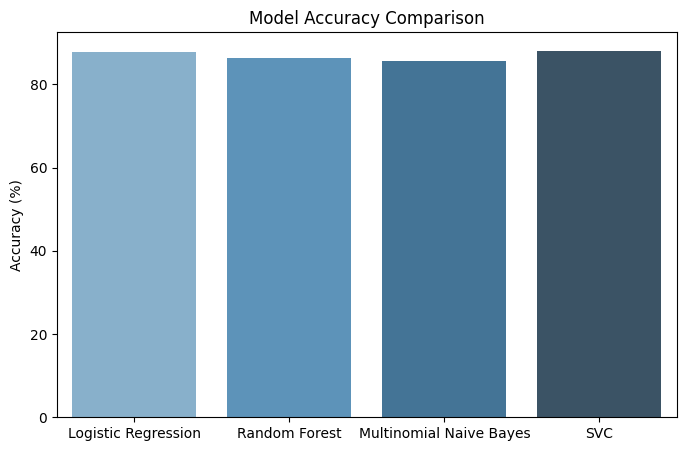

In [ ]:
# Model accuracies
models = ['Logistic Regression', 'Random Forest', 'Multinomial Naive Bayes', 'SVC']
accuracies = [87.83, 86.28, 85.69, 88.12]

# Plot the model accuracies
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='Blues_d')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.show()


## Result & Conclution

After thorough training and testing of multiple models; I have achieved the following result (or accuracies):

1. Logistic Regression: 87.83%
2. Random Forest Classifier: 86.28%
3. Multinomial Naive Bayes: 85.69%
4. Support Vector Classifier: 88.12%


Clearly the Support Vector Classifier ML model provides the most accuracy.
